In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from imblearn.over_sampling import SMOTE

C:\ProgramData\Anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
FILES = ["S07main_EpochedNoseRefCleanTimesFixed.mat"]   # add more subjects here
FSAMPLE     = 512
TOTAL_TIMES = 1229
T_STIMULUS  = 822   # index of stimulus onset (t=0 s)
T_POST      = 407   # post-stimulus samples
BANDS = {"delta":(1,4), "theta":(4,8), "alpha":(8,13), "beta":(13,30)}

In [3]:
#method to load data
def get_field(struct, name):
    f = struct[name]
    if f.dtype == object:
        out = []
        for item in f.flatten():
            if isinstance(item, np.ndarray):
                out.append(item[0,0] if item.size==1 and item.ndim>1 else (item[0] if item.size==1 else item))
            else:
                out.append(item)
        return out
    return f.flatten() if f.size > 1 else f[0,0]

def load_files(files):
    vals, trials = [], []
    for f in files:
        dc = loadmat(f)["dataClean"][0,0]
        t  = np.array(get_field(dc, "trial"))
        ti = np.array(get_field(dc, "trialinfo")).reshape(len(t), 5)
        v  = ti[:, 1]
        vals.extend(v); trials.extend(t)
    trials = np.array(trials); vals = np.array(vals)
    mask   = (vals != -1) & (vals != 0)
    return vals[mask] - 1, trials[mask]   # labels {0,1}, trials

In [4]:
y, all_trials = load_files(FILES)
X_full = all_trials.transpose(0, 2, 1)   # (trials, timesteps, channels)
print(f"Trials: {len(y)}  |  Class 0: {(y==0).sum()}  Class 1: {(y==1).sum()}")

#split data
X_tr_raw, X_tmp, y_train, y_tmp = train_test_split(X_full, y, test_size=0.4, random_state=42)
X_val_raw, X_te_raw, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42)

#normalise data
mean = X_tr_raw.mean(axis=(0,1), keepdims=True)
std  = X_tr_raw.std(axis=(0,1),  keepdims=True) + 1e-6
X_train = (X_tr_raw  - mean) / std
X_val   = (X_val_raw - mean) / std
X_test  = (X_te_raw  - mean) / std
print(f"Train/Val/Test: {len(y_train)}/{len(y_val)}/{len(y_test)}")


Trials: 222  |  Class 0: 134  Class 1: 88
Train/Val/Test: 133/44/45


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

#defining transformer architecture
class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model=32, nhead=4, layers=2, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4*d_model,
            dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=layers)
        self.fc = nn.Linear(d_model, 1)
    def forward(self, x):
        x = self.proj(x)
        x = self.encoder(x)
        return torch.sigmoid(self.fc(x.mean(dim=1)))

#training transformer modek
def train_transformer(X, y_lbl, epochs=30, batch_size=32, lr=1e-3):
    loader = DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32),
                      torch.tensor(y_lbl, dtype=torch.float32)),
        batch_size=batch_size, shuffle=True)
    model   = TransformerModel(X.shape[2]).to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(model(xb).squeeze(), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    return model

def predict_transformer(model, X):
    model.eval()
    with torch.no_grad():
        p = model(torch.tensor(X, dtype=torch.float32).to(device)).squeeze().cpu().numpy()
    return (p > 0.5).astype(int)

Device: cpu


In [6]:
def show_results(name, y_true, y_pred):
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(classification_report(y_true, y_pred, target_names=["Class 0","Class 1"], digits=4))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Class 0","Class 1"], yticklabels=["Class 0","Class 1"])
    plt.title(name); plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()

Training Transformer (normal)...

  Transformer — Normal data
              precision    recall  f1-score   support

     Class 0     0.5185    0.5600    0.5385        25
     Class 1     0.3889    0.3500    0.3684        20

    accuracy                         0.4667        45
   macro avg     0.4537    0.4550    0.4534        45
weighted avg     0.4609    0.4667    0.4629        45



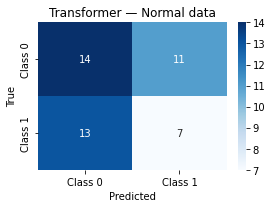


Training Transformer (SMOTE) — 164 trials...

  Transformer — SMOTE data
              precision    recall  f1-score   support

     Class 0     0.5217    0.4800    0.5000        25
     Class 1     0.4091    0.4500    0.4286        20

    accuracy                         0.4667        45
   macro avg     0.4654    0.4650    0.4643        45
weighted avg     0.4717    0.4667    0.4683        45



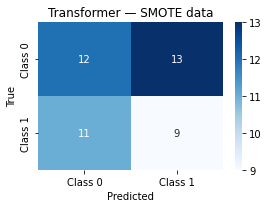

In [7]:
#transformer trained on raw data
print("Training Transformer (normal)...")
model_normal = train_transformer(X_train, y_train)
show_results("Transformer — Normal data", y_test, predict_transformer(model_normal, X_test))

#transformer trained on SMOTE data
n, t, ch = X_train.shape
Xf_sm, y_sm = SMOTE(random_state=42).fit_resample(X_train.reshape(n, -1), y_train)
X_sm = Xf_sm.reshape(-1, t, ch)
print(f"\nTraining Transformer (SMOTE) — {len(y_sm)} trials...")
model_smote = train_transformer(X_sm, y_sm)
show_results("Transformer — SMOTE data", y_test, predict_transformer(model_smote, X_test))